In [1]:
import numpy as np

X_all = np.load(r"MNIST_Dataset/X_mnist_all.npy")
y_all = np.load(r"MNIST_Dataset/y_mnist_all.npy")

In [2]:
print(X_all.shape)  # (70000, 28, 28)
print(y_all.shape)  # (70000,)

(70000, 28, 28)
(70000,)


In [3]:
print("Number of classes:", len(np.unique(y_all)))

Number of classes: 10


In [4]:
import matplotlib.pyplot as plt

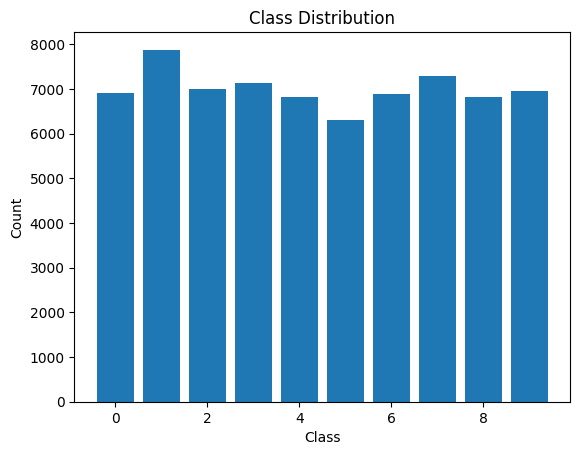

In [5]:
# Class distribution
unique, counts = np.unique(y_all, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

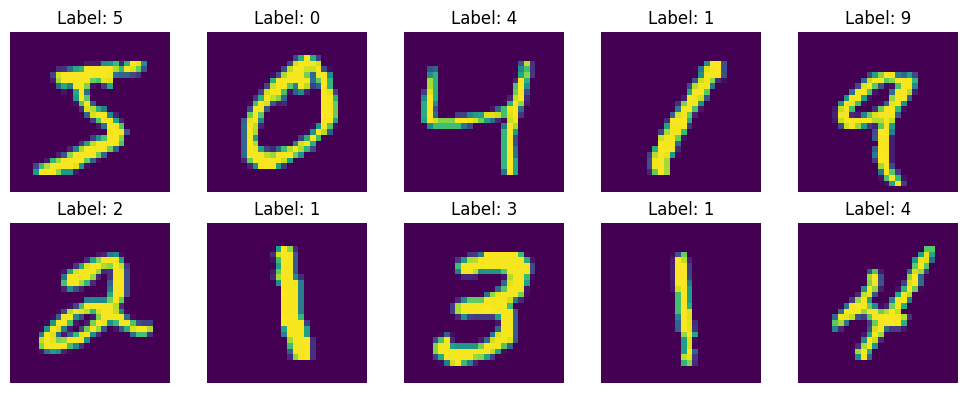

In [6]:
# Visualize some samplesplt.
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_all[i])
    plt.title(f"Label: {y_all[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(X_train.shape)  # ~56000
print(X_test.shape)   # ~14000


(56000, 28, 28)
(14000, 28, 28)


In [8]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

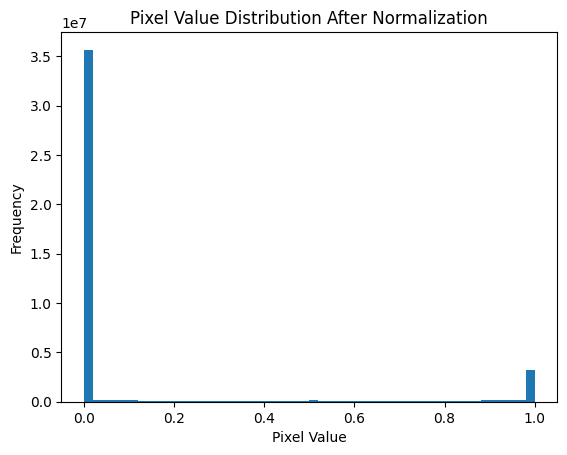

In [9]:
plt.hist(X_train.flatten(), bins=50)
plt.title("Pixel Value Distribution After Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

that means that the images almost all are black and wight 

In [10]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test, num_classes=10)

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(28, 28)),   # 784 input nodes
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### Model Architecture Analysis
- Flatten layer converts image to 1D vector
- Dense layers learn feature representations
- Dropout reduces overfitting
- Output layer uses softmax for multi-class classification


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [14]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8995 - loss: 0.3338 - val_accuracy: 0.9538 - val_loss: 0.1438
Epoch 2/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.9501 - loss: 0.1640 - val_accuracy: 0.9613 - val_loss: 0.1202
Epoch 3/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9608 - loss: 0.1278 - val_accuracy: 0.9689 - val_loss: 0.0971
Epoch 4/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9641 - loss: 0.1141 - val_accuracy: 0.9691 - val_loss: 0.0939
Epoch 5/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9687 - loss: 0.0968 - val_accuracy: 0.9741 - val_loss: 0.0824
Epoch 6/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.9718 - loss: 0.0889 - val_accuracy: 0.9732 - val_loss: 0.0864
Epoch 7/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.9738 - loss: 0.0809 - val_accuracy: 0.9752 - val_loss: 0.0874
Epoch 8/10
1575/1575 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9763 - los

### Training Analysis

The model shows steady improvement across epochs.
Both training and validation accuracy increase consistently and converge around 97.7%.
The validation loss remains stable and close to training loss, indicating good generalization and no signs of overfitting.

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

438/438 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9765 - loss: 0.0863
Test Accuracy: 0.9765
Test Loss: 0.0863


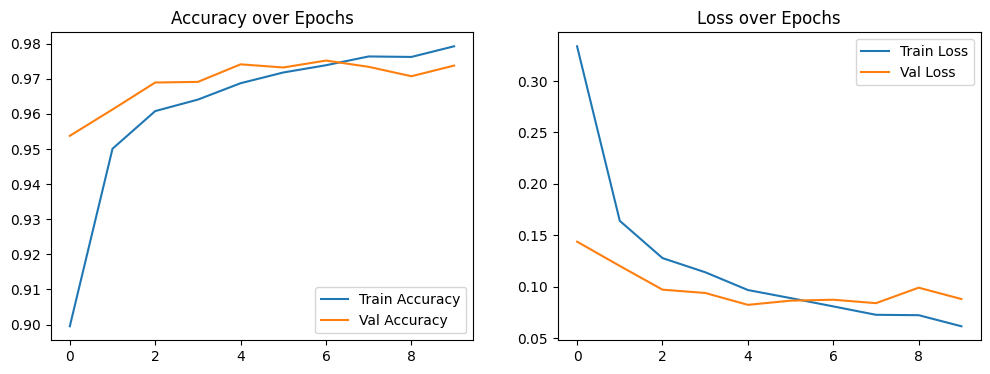

In [16]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss over Epochs")

plt.show()


In [17]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(confusion_matrix(y_test, y_pred))

438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
[[1367    1    0    0    0    2    2    1    4    4]
 [   0 1553    4    4    1    3    1    5    2    2]
 [   5    6 1365    4    4    0    1    3    6    4]
 [   0    1    6 1358    0   45    0   10    5    3]
 [   2    4    1    0 1335    0    3    2    0   18]
 [   2    0    0    3    1 1245    5    0    3    4]
 [  11    1    0    1   11    6 1343    0    1    1]
 [   1    4    6    0    6    2    0 1433    0    7]
 [   6    4    2    7    2   12    4    1 1314   13]
 [   1    7    0    1   10    8    0    5    1 1358]]


In [18]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # predicted class labels
y_true = np.argmax(y_test_cat, axis=1)     # true class labels

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


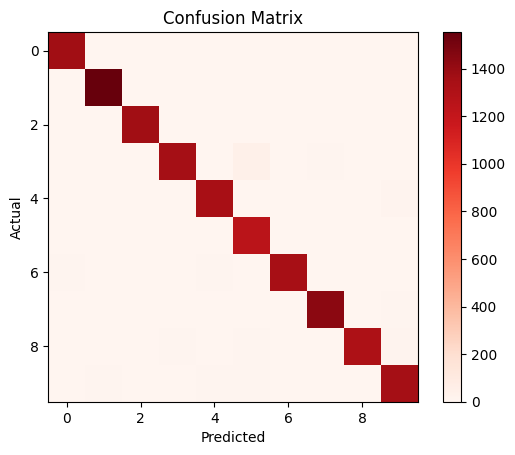

In [19]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.imshow(cm, cmap='Reds')
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.99      0.98      1575
           2       0.99      0.98      0.98      1398
           3       0.99      0.95      0.97      1428
           4       0.97      0.98      0.98      1365
           5       0.94      0.99      0.96      1263
           6       0.99      0.98      0.98      1375
           7       0.98      0.98      0.98      1459
           8       0.98      0.96      0.97      1365
           9       0.96      0.98      0.97      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



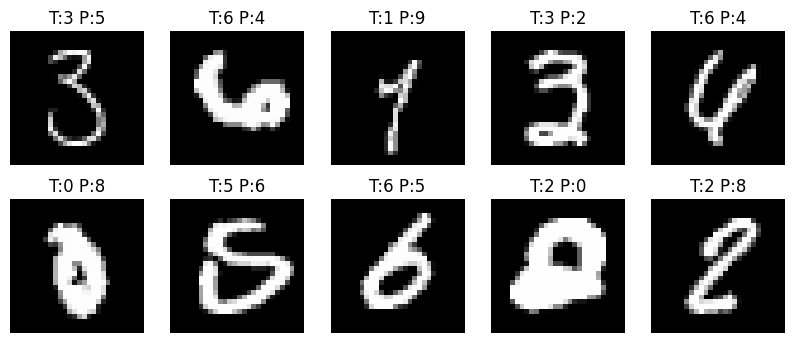

In [21]:
mis_idx = np.where(y_pred_classes != y_true)[0]

plt.figure(figsize=(10,4))
for i, idx in enumerate(mis_idx[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"T:{y_true[idx]} P:{y_pred_classes[idx]}")
    plt.axis("off")
plt.show()

## Applying Grad-CAM to see Why did the model predict class X?

❌ Grad-CAM does NOT work well with a pure Dense model and ours is pure dense, so..

```
👉 Best practice:
        Add at least one Conv2D layer
```

Conv2D is a layer that learns to detect visual patterns (edges, shapes, textures) by sliding small filters over an image.

```
Pixel (10,10) and pixel (10,11)
    Dense layer: ❌ unrelated
    Human vision: ✅ neighbors
```

```
What Conv2D actually does 🔍

Slides over the image
    Looks at all pixels at a time
    Computes a weighted sum
    Produces one value
    That value answers:
    “Did I see a specific pattern here?”
```

In [22]:
from tensorflow.keras import layers, models

In [23]:
model_Grad_CAM = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model_Grad_CAM.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_Grad_CAM.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model_Grad_CAM.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=32
)

Epoch 1/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9598 - loss: 0.1308 - val_accuracy: 0.9813 - val_loss: 0.0589
Epoch 2/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 61s 35ms/step - accuracy: 0.9865 - loss: 0.0443 - val_accuracy: 0.9827 - val_loss: 0.0518
Epoch 3/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 63s 36ms/step - accuracy: 0.9902 - loss: 0.0303 - val_accuracy: 0.9879 - val_loss: 0.0386
Epoch 4/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 90s 41ms/step - accuracy: 0.9930 - loss: 0.0217 - val_accuracy: 0.9884 - val_loss: 0.0376
Epoch 5/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 77s 44ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9890 - val_loss: 0.0344
Epoch 6/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 90s 51ms/step - accuracy: 0.9955 - loss: 0.0133 - val_accuracy: 0.9906 - val_loss: 0.0338
Epoch 7/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 129s 44ms/step - accuracy: 0.9971 - loss: 0.0090 - val_accuracy: 0.9855 - val_loss: 0.0525
Epoch 8/10
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 74s 42ms/step - accuracy: 0.9973 

In [27]:
test_loss, test_accuracy = model_Grad_CAM.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")


438/438 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9909 - loss: 0.0399
Test Accuracy: 0.9909
Test Loss: 0.0399


In [28]:
y_pred_CAM = model_Grad_CAM.predict(X_test)
y_pred_classes = np.argmax(y_pred_CAM, axis=1) # predicted class labels
y_true = np.argmax(y_test_cat, axis=1)     # true class labels

438/438 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


In [29]:
mis_idx = np.where(y_pred_classes != y_true)[0]

In [30]:
len(mis_idx), len(y_pred_CAM)

(127, 14000)

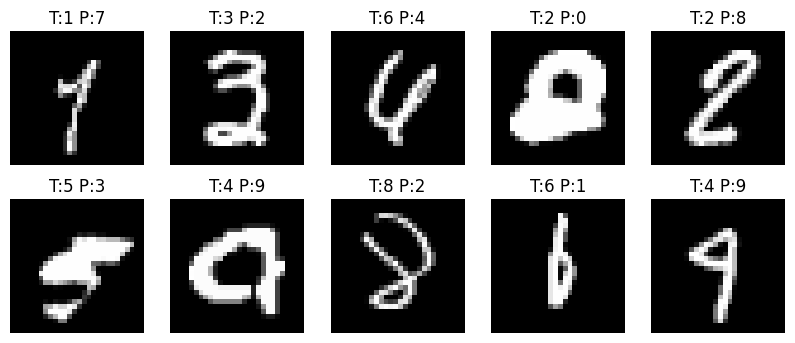

In [31]:
plt.figure(figsize=(10,4))
for i, idx in enumerate(mis_idx[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"T:{y_true[idx]} P:{y_pred_classes[idx]}")
    plt.axis("off")
plt.show()

In [32]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    img_array = tf.convert_to_tensor(img_array)
    _ = model(img_array)
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.layers[-1].output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        tape.watch(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val
    else:
        heatmap = tf.zeros_like(heatmap)
    return heatmap.numpy()

In [38]:
img_num = 9
img = X_test[mis_idx[img_num]]               # one image
img_array = np.expand_dims(img, axis=0)

In [39]:
# Force build the model by running a dummy forward pass
_ = model_Grad_CAM.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


In [40]:
model_Grad_CAM(img_array)  # This builds the graph without printing output

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[8.6176089e-14, 2.7680967e-12, 7.6805159e-12, 3.6258763e-11,
        9.8705094e-04, 9.1424665e-13, 3.7907736e-14, 1.4609028e-09,
        1.2834727e-07, 9.9901283e-01]], dtype=float32)>

In [41]:
heatmap = make_gradcam_heatmap(
    img_array,
    model_Grad_CAM,
    last_conv_layer_name="conv2d_1"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

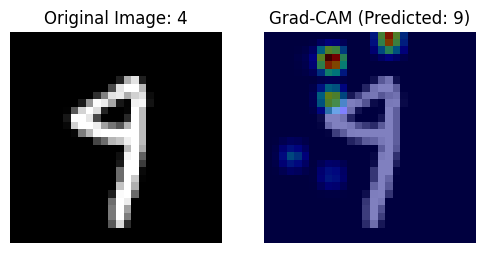

In [42]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Original Image: {y_true[mis_idx[img_num]]}")
plt.axis("off")

# --- Added Code Starts ---
preds = model_Grad_CAM.predict(np.expand_dims(img, axis=0))
predicted_label = np.argmax(preds[0])
# --- Added Code Ends ---

plt.subplot(1,2,2)
plt.imshow(img.squeeze(), cmap="gray")
heatmap_resized = cv2.resize(heatmap, (28, 28))
plt.imshow(heatmap_resized, cmap="jet", alpha=0.5)
plt.title(f"Grad-CAM (Predicted: {predicted_label})") # Updated title
plt.axis("off")